# 04 — Cross-task benchmark summary

Reads every `results/*.json` written by notebooks 01–03 and produces the consolidated
tables and figures for the report. Run the three benchmark notebooks first; this one
does no training of its own.

In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common
from common import RESULTS, FAMILY_COLORS, env_info

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

tasks = {}
for p in sorted(RESULTS.glob("*.json")):
    rows = json.loads(p.read_text())
    if not isinstance(rows, list):  # e.g. latest_generalization.json, not a ResultStore table
        continue
    recs = []
    for r in rows:
        rec = {"task": r["task"], "model": r["model"], "family": r["family"]}
        rec.update(r["metrics"])
        rec["train_s"] = r.get("train_seconds")
        rec["infer_ms"] = r.get("infer_ms_per_item")
        rec["size_mb"] = r.get("model_size_mb")
        rec["n_params"] = r.get("n_params")
        rec["notes"] = r.get("notes", "")
        recs.append(rec)
    tasks[p.stem] = pd.DataFrame(recs)
    print(f"{p.stem}: {len(recs)} models")

intent_classification: 28 models
intent_latest_models: 4 models
intent_robustness_shift: 5 models
priority_latest_models: 4 models
router_image_classification: 15 models
voice_asr: 5 models


## 1. Intent classification (text)

In [2]:
t = tasks.get("intent_classification")
if t is not None:
    sup = t[t.family != "unsupervised"].sort_values("macro_f1", ascending=False)
    print(sup[["model", "family", "accuracy", "balanced_acc", "macro_f1", "weighted_f1",
               "top3_accuracy", "train_s", "infer_ms", "size_mb"]].round(4).to_string(index=False))
    print("\nunsupervised:")
    uns = t[t.family == "unsupervised"].sort_values("ARI", ascending=False)
    print(uns[["model", "ARI", "NMI", "V_measure", "purity", "hungarian_acc",
               "n_clusters"]].round(4).to_string(index=False))
    sup.to_csv(RESULTS / "summary_intent_supervised.csv", index=False)
    uns.to_csv(RESULTS / "summary_intent_unsupervised.csv", index=False)

                      model      family  accuracy  balanced_acc  macro_f1  weighted_f1  top3_accuracy  train_s  infer_ms  size_mb
     tfidf_word+char+linsvc traditional    0.9992        0.9991    0.9991       0.9992            NaN   8.0129    1.5223     1.96
           minilm_finetuned        deep    0.9969        0.9968    0.9966       0.9969         0.9994  46.8779    5.5220    87.38
       distilbert_finetuned        deep    0.9961        0.9956    0.9956       0.9961         1.0000  82.8707    6.1289   256.18
              minilm+linsvc   embedding    0.9953        0.9947    0.9946       0.9953            NaN   7.6898    6.1615     0.08
              minilm+mlp256   embedding    0.9939        0.9933    0.9933       0.9939         0.9992   3.3828    6.1615     1.12
              minilm+logreg   embedding    0.9931        0.9922    0.9923       0.9931         0.9994   0.7940    6.1615     0.04
          tfidf_word+logreg traditional    0.9922        0.9905    0.9912       0.9922    

## 2. Router crop classification (vision)

In [3]:
t = tasks.get("router_image_classification")
if t is not None:
    sup = t[t.family != "unsupervised"].sort_values("macro_f1", ascending=False)
    print(sup[["model", "family", "accuracy", "balanced_acc", "macro_f1", "weighted_f1",
               "train_s", "infer_ms", "size_mb"]].round(4).to_string(index=False))
    print("\nunsupervised:")
    uns = t[t.family == "unsupervised"].sort_values("ARI", ascending=False)
    print(uns[["model", "ARI", "NMI", "purity", "hungarian_acc", "n_clusters"]]
          .round(4).to_string(index=False))
    sup.to_csv(RESULTS / "summary_router_supervised.csv", index=False)

                           model      family  accuracy  balanced_acc  macro_f1  weighted_f1  train_s  infer_ms  size_mb
   efficientnet_b0_frozen+logreg   embedding    0.9704        0.9813    0.9774       0.9713   0.1552       NaN     0.09
       efficientnet_b0_finetuned        deep    0.9630        0.9821    0.9728       0.9637 405.5091   12.6514    15.65
          resnet18_frozen+logreg   embedding    0.9481        0.9565    0.9567       0.9468   0.2803       NaN     0.04
    mobilenet_v3_small_finetuned        deep    0.9630        0.9793    0.9488       0.9647 344.9282    8.5433     5.98
mobilenet_v3_small_frozen+logreg   embedding    0.9556        0.9739    0.9456       0.9585   0.1343       NaN     0.07
              resnet18_finetuned        deep    0.9630        0.9821    0.8999       0.9667 377.2398    4.5667    42.74
         colourhist+randomforest traditional    0.8667        0.8114    0.7723       0.8605   0.9912   80.0826     9.11
        hog+colour+pca200+histgb traditi

## 3. Voice / ASR

In [4]:
t = tasks.get("voice_asr")
if t is not None:
    cols = [c for c in ["model", "wer", "cer", "embed_cos", "rtf", "lang_id_acc",
                        "chrf2", "bleu", "n_calls", "notes"] if c in t.columns]
    print(t[cols].round(4).sort_values("wer").to_string(index=False))
    t.to_csv(RESULTS / "summary_voice.csv", index=False)

                     model    wer    cer  embed_cos    rtf  lang_id_acc   chrf2    bleu  n_calls                                                                         notes
      faster_whisper_small 0.1838 0.1390     0.9171 0.0837          1.0     NaN     NaN        2 quantised runtime + VAD silence skipping, same Whisper weights; ran on cached
             whisper_small 0.1892 0.1437     0.8794 0.0990          1.0     NaN     NaN        2                       duration-weighted; references are cleaned, not verbatim
              whisper_base 0.2925 0.2100     0.8585 0.0661          1.0     NaN     NaN        2                       duration-weighted; references are cleaned, not verbatim
              whisper_tiny 0.3657 0.2548     0.8528 0.0409          1.0     NaN     NaN        2                       duration-weighted; references are cleaned, not verbatim
whisper_small_translate_en 0.7032 0.5442     0.6632 0.1619          NaN 50.6587 23.5991        9                             

## 4. Winner per task and per family

In [5]:
rows = []
for name, df in tasks.items():
    metric = "wer" if name == "voice_asr" else "macro_f1"
    if metric not in df.columns:
        continue
    d = df.dropna(subset=[metric])
    for fam, grp in d.groupby("family"):
        best = grp.loc[grp[metric].idxmin() if metric == "wer" else grp[metric].idxmax()]
        rows.append({"task": name, "family": fam, "best_model": best["model"],
                     metric: round(float(best[metric]), 4),
                     "train_s": best.get("train_s"), "infer_ms": best.get("infer_ms")})
winners = pd.DataFrame(rows)
print(winners.to_string(index=False))
winners.to_csv(RESULTS / "summary_winners.csv", index=False)

                       task      family                    best_model  macro_f1    train_s  infer_ms    wer
      intent_classification        deep              minilm_finetuned    0.9966  46.877856   5.52205    NaN
      intent_classification   embedding                 minilm+linsvc    0.9946   7.689798   6.16150    NaN
      intent_classification traditional        tfidf_word+char+linsvc    0.9991   8.012908   1.52225    NaN
       intent_latest_models        deep               xlnet_finetuned    0.9974 339.112028  16.44750    NaN
       intent_latest_models   embedding           laya_encoder+logreg    0.9742   0.762904  25.51665    NaN
    intent_robustness_shift        deep          distilbert_finetuned    0.9582  44.532692       NaN    NaN
    intent_robustness_shift   embedding                 minilm+logreg    0.9779   1.062621       NaN    NaN
    intent_robustness_shift traditional        tfidf_word+char+linsvc    0.9943   2.328875       NaN    NaN
     priority_latest_models 

## 5. Consolidated figure

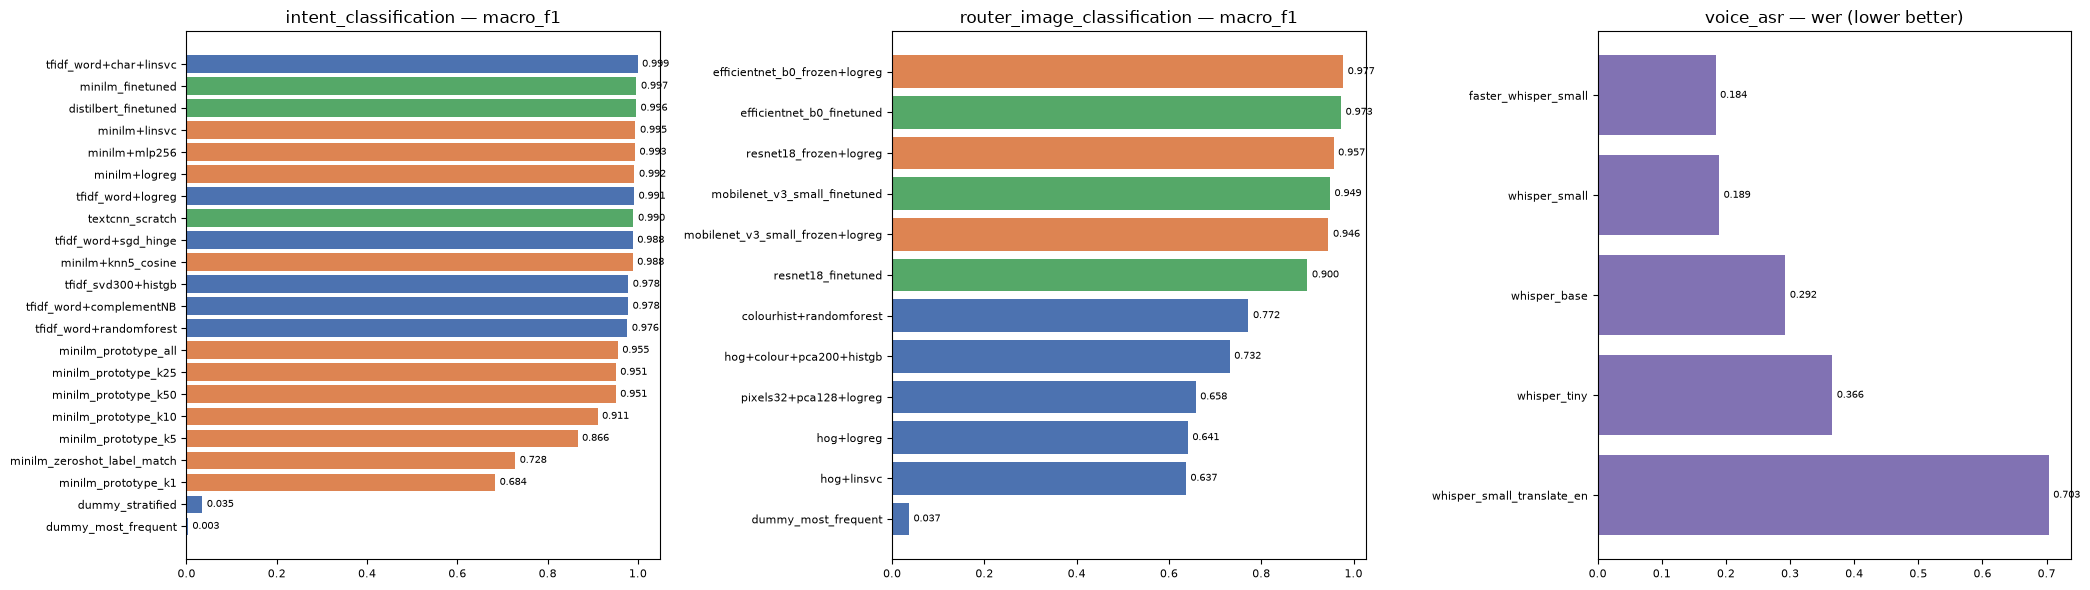

In [6]:
plot_tasks = [(k, "macro_f1") for k in ("intent_classification", "router_image_classification")
              if k in tasks] + ([("voice_asr", "wer")] if "voice_asr" in tasks else [])

fig, axes = plt.subplots(1, len(plot_tasks), figsize=(7 * len(plot_tasks), 6))
axes = np.atleast_1d(axes)
for ax, (name, metric) in zip(axes, plot_tasks):
    d = tasks[name].dropna(subset=[metric])
    d = d[d.family != "unsupervised"] if metric == "macro_f1" else d
    d = d.sort_values(metric, ascending=(metric != "wer"))
    ax.barh(d["model"], d[metric],
            color=[FAMILY_COLORS.get(f, "#888") for f in d["family"]])
    for i, v in enumerate(d[metric]):
        ax.text(v + d[metric].max() * 0.01, i, f"{v:.3f}", va="center", fontsize=7)
    ax.set_title(f"{name} — {metric}" + (" (lower better)" if metric == "wer" else ""))
    ax.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "summary_all_tasks.png", dpi=150)
plt.show()

## 6. Cost/benefit view — accuracy against training time

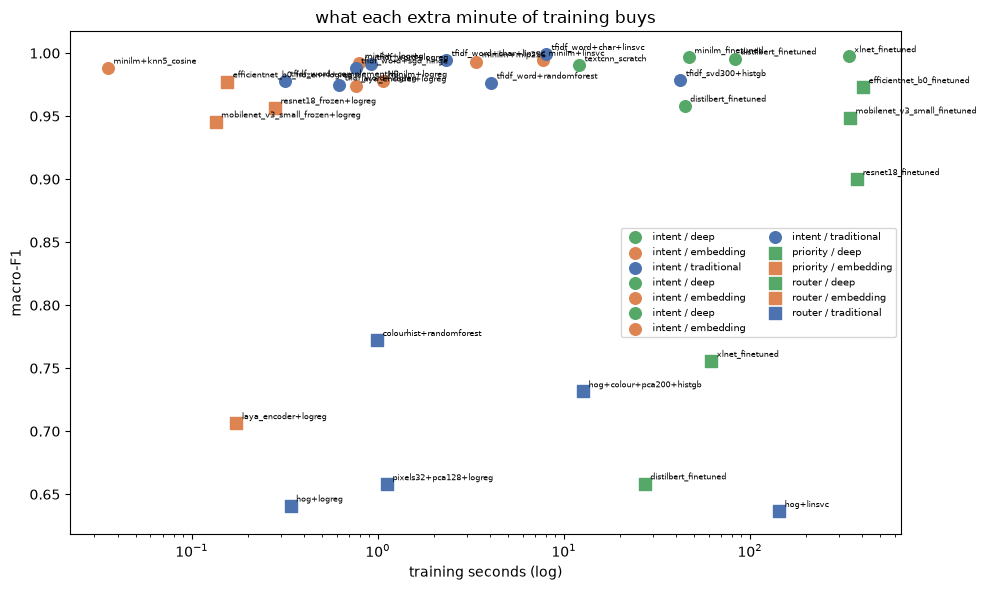

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
for name, df in tasks.items():
    if "macro_f1" not in df.columns:
        continue
    d = df.dropna(subset=["macro_f1", "train_s"])
    d = d[d["train_s"] > 0]
    marker = "o" if "intent" in name else "s"
    for fam, grp in d.groupby("family"):
        ax.scatter(grp["train_s"], grp["macro_f1"], marker=marker, s=70,
                   color=FAMILY_COLORS.get(fam, "#888"),
                   label=f"{name.split('_')[0]} / {fam}")
        for _, r in grp.iterrows():
            ax.annotate(r["model"], (r["train_s"], r["macro_f1"]), fontsize=6,
                        xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("training seconds (log)"); ax.set_ylabel("macro-F1")
ax.set_title("what each extra minute of training buys")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig(RESULTS / "summary_cost_benefit.png", dpi=150); plt.show()

## 7. Markdown report block

Paste the output below straight into the project documentation.

In [8]:
lines = ["# Model benchmark summary", "",
         f"Environment: `{json.dumps(env_info())}`", ""]
for name, df in tasks.items():
    metric = "wer" if name == "voice_asr" else "macro_f1"
    if metric not in df.columns:
        continue
    d = df.dropna(subset=[metric]).sort_values(metric, ascending=(metric == "wer"))
    lines += [f"## {name}", ""]
    cols = [c for c in ["model", "family", "accuracy", "macro_f1", "wer", "cer", "rtf",
                        "lang_id_acc", "train_s", "infer_ms", "size_mb"] if c in d.columns]
    lines.append(d[cols].round(4).to_markdown(index=False))
    lines.append("")
report = "\n".join(lines)
(RESULTS / "BENCHMARK_REPORT.md").write_text(report, encoding="utf-8")
print(report[:3000])
print(f"\nwritten -> {RESULTS / 'BENCHMARK_REPORT.md'}")

# Model benchmark summary

Environment: `{"python": "3.13.12", "platform": "Windows-11-10.0.26200-SP0", "torch": "2.13.0+cu132", "cuda_available": true, "gpu": "NVIDIA GeForce RTX 4050 Laptop GPU", "vram_gb": 6.0}`

## intent_classification

| model                       | family      |   accuracy |   macro_f1 |   train_s |   infer_ms |   size_mb |
|:----------------------------|:------------|-----------:|-----------:|----------:|-----------:|----------:|
| tfidf_word+char+linsvc      | traditional |     0.9992 |     0.9991 |    8.0129 |     1.5223 |      1.96 |
| minilm_finetuned            | deep        |     0.9969 |     0.9966 |   46.8779 |     5.522  |     87.38 |
| distilbert_finetuned        | deep        |     0.9961 |     0.9956 |   82.8707 |     6.1289 |    256.18 |
| minilm+linsvc               | embedding   |     0.9953 |     0.9946 |    7.6898 |     6.1615 |      0.08 |
| minilm+mlp256               | embedding   |     0.9939 |     0.9933 |    3.3828 |     6.1615 |      1.